# Showcase of SMPL based model ROMP (REGRESSION)
https://github.com/Arthur151/ROMP/tree/master/simple_romp

Monocular, One-stage, Regression of Multiple 3D People (https://arxiv.org/pdf/2008.12272)  
ROMP is a one-stage method for monocular multi-person 3D mesh recovery in real time.  
Good for multi-person but not sota anymore.

In [ ]:
import os
import cv2
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Video
from mpl_toolkits.mplot3d import Axes3D
import mediapipe as mp

#!pip install smplx
#!pip install pyrender
import torch
import smplx
import pyrender
import trimesh

## ROMP on an image (Single Person)

In [2]:
!romp --mode=image --calc_smpl --render_mesh -i="D:\repos\AAI2_2026_Motion_Capture.github.io\test\man_test_image.jpg" -o="D:\repos\AAI2_2026_Motion_Capture.github.io\test\man_test_result.jpg"

Using ROMP v1


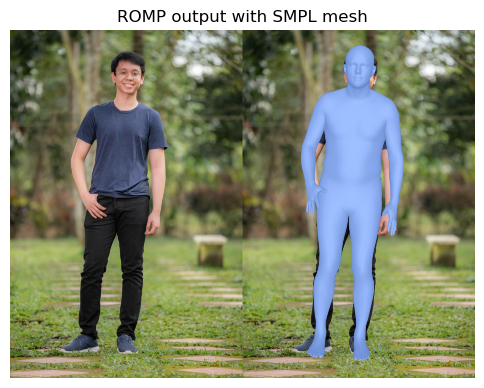

In [3]:
result_path = r"D:\repos\AAI2_2026_Motion_Capture.github.io\test\man_test_result.jpg"
result = Image.open(result_path)

plt.figure(figsize=(6, 8))
plt.imshow(result)
plt.axis("off")
plt.title("ROMP output with SMPL mesh")
plt.show()

## ROMP on an image (Multi Person)

In [4]:
!romp --mode=image --calc_smpl --render_mesh -i="./test/group_image.jpg" -o="./test/group_result.jpg"

Using ROMP v1


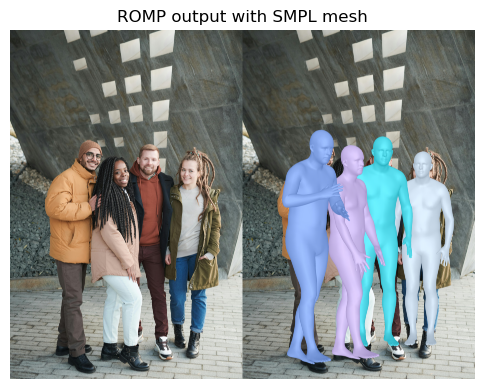

In [5]:
result_path = r"./test/group_result.jpg"
result = Image.open(result_path)

plt.figure(figsize=(6, 8))
plt.imshow(result)
plt.axis("off")
plt.title("ROMP output with SMPL mesh")
plt.show()

## ROMP on video
Known issue: person not detected -> no frame created -> reconstruction pipeline fails. Therefore manual reconstruction needed

In [ ]:
!romp --mode=video --calc_smpl --render_mesh --onnx --show_largest\
-i="./test/man_walking_test.mp4" \
-o="./test/video_result/man_walking_result.mp4" \
--save_video

In [ ]:
frame_dir = r"D:\repos\AAI2_2026_Motion_Capture.github.io\test\video_result"
output_video = os.path.join(frame_dir, "reconstructed.mp4")

frames = sorted(glob(os.path.join(frame_dir, "*.jpg")))
if not frames:
    frames = sorted(glob(os.path.join(frame_dir, "*.png")))

if not frames:
    raise ValueError("No frame images found.")

first = cv2.imread(frames[0])
h, w = first.shape[:2]

fps = 30 

writer = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

for f in frames:
    img = cv2.imread(f)
    if img is not None:
        writer.write(img)

writer.release()
print("Saved:", output_video)

In [6]:
Video("output.mp4", embed=True)

## How does it work?

1. Input → 2. Feature extraction → 3. Parameter regression → 4. SMPL body reconstruction → 5. Rendering / output.

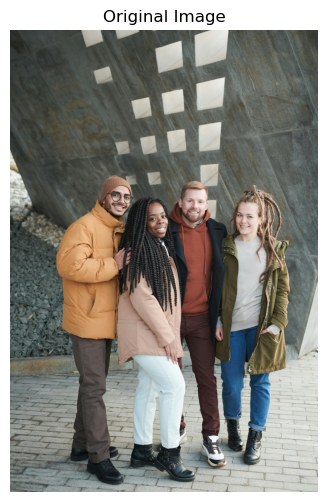

In [7]:
img1 = Image.open(r"./test/group_image.jpg")

plt.figure(figsize=(12, 6))
plt.imshow(img1)
plt.axis("off")
plt.title("Original Image")
plt.show()

### Feature extraction
Body Center heatmap, a Camera map, and an SMPL map; together, the camera and SMPL maps form the mesh-parameter map. (CNNs)


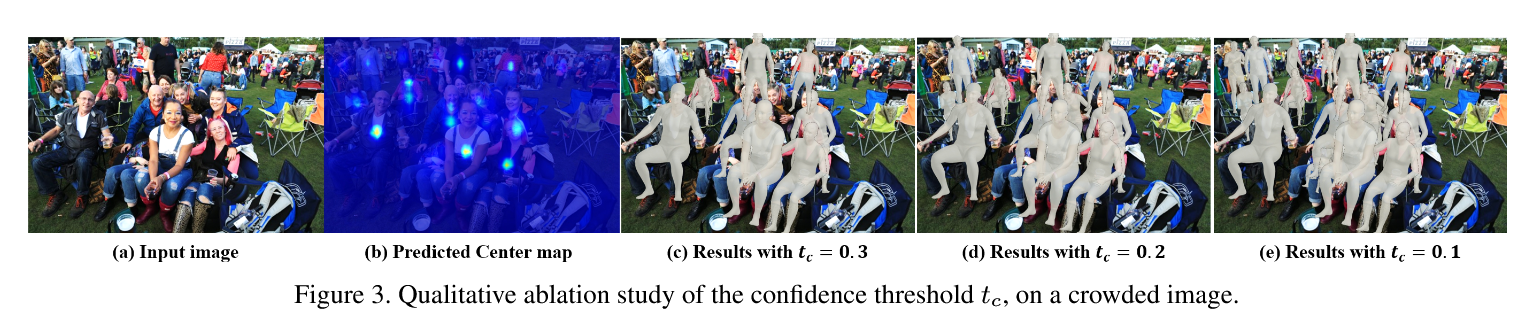

### Parameter Regression
Instead of detecting people first and then estimating pose, ROMP does everything in one shot. From the heatmaps / features we get Pose parameters (θ), Shape parameters (β) and Camera parameters (c).

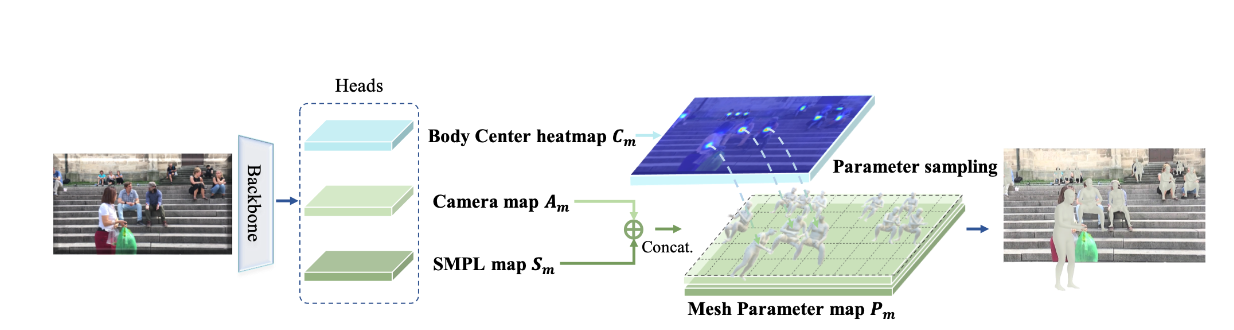

### SMPL Body Construction
SMPL expects Pose (θ) and Shape (β). Those values we get through the parameter regression. The SMPL model creates 3D vertices(mesh) + 3D joints

In [9]:
model_path = "./smpl_model_data/SMPL_NEUTRAL.pkl"

# Create SMPL model
smpl = smplx.create(
    model_path,
    model_type='smpl',
    gender='neutral',
    batch_size=1
)

# ---- INPUT PARAMETERS ----

# Shape parameters (β)
betas = torch.zeros(1, 10)

# Pose parameters (θ)
global_orient = torch.zeros(1, 3)

# body pose (23 joints × 3 = 69 dims)
body_pose = torch.zeros(1, 69)

joint_id = 16
body_pose[0, joint_id * 3 + 0] = 0.0   
body_pose[0, joint_id * 3 + 1] = 0.0   
body_pose[0, joint_id * 3 + 2] = 1.0   

# ---- FORWARD PASS ----
output = smpl(
    betas=betas,
    global_orient=global_orient,
    body_pose=body_pose,
    return_verts=True
)

# ---- OUTPUT ----
vertices = output.vertices        # (1, 6890, 3)
joints = output.joints            # (1, 24, 3)

In [ ]:
verts = vertices[0].detach().cpu().numpy()
faces = smpl.faces

mesh = trimesh.Trimesh(verts, faces)
mesh = pyrender.Mesh.from_trimesh(mesh)

scene = pyrender.Scene()
scene.add(mesh)

viewer = pyrender.Viewer(scene, use_raymond_lighting=True)

### Final Output / Rendering
ROMP predicts a weak-perspective camera, usually scale + 2D translation. Then it maps every 3D point to 2D to construct the mesh on the image.


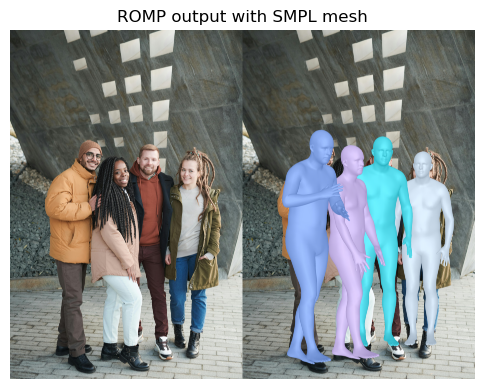

In [5]:
result_path = r"./test/group_result.jpg"
result = Image.open(result_path)

plt.figure(figsize=(6, 8))
plt.imshow(result)
plt.axis("off")
plt.title("ROMP output with SMPL mesh")
plt.show()

Other regression based models: PARE (single person), HMR (baseline), METRO

# Showcase of MediaPipe (2D / 3D joint locations)

In [15]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

In [19]:
options = mp.tasks.vision.PoseLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path="./model/pose_landmarker_lite.task"),
    running_mode=mp.tasks.vision.RunningMode.IMAGE,
)

img = cv2.imread("./test/man_test_image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Numpy image to MediaPipe Image
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

# Run pose detection
with mp.tasks.vision.PoseLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(mp_image)
    
print(result)

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5068752765655518, y=0.14885684847831726, z=-0.429300457239151, visibility=0.9999628067016602, presence=0.9998546838760376), NormalizedLandmark(x=0.5228601098060608, y=0.1317150592803955, z=-0.38951730728149414, visibility=0.9999008178710938, presence=0.9996488094329834), NormalizedLandmark(x=0.5323275923728943, y=0.1322280764579773, z=-0.3897620737552643, visibility=0.9998939037322998, presence=0.9996324777603149), NormalizedLandmark(x=0.5408123731613159, y=0.13273051381111145, z=-0.3899002969264984, visibility=0.9999048709869385, presence=0.9995974898338318), NormalizedLandmark(x=0.4932231605052948, y=0.1311422884464264, z=-0.3875288665294647, visibility=0.9998921155929565, presence=0.9996575117111206), NormalizedLandmark(x=0.4830637574195862, y=0.1311028003692627, z=-0.3875291645526886, visibility=0.9998838901519775, presence=0.9996615648269653), NormalizedLandmark(x=0.4735347032546997, y=0.13120588660240173, z=-0.387557148

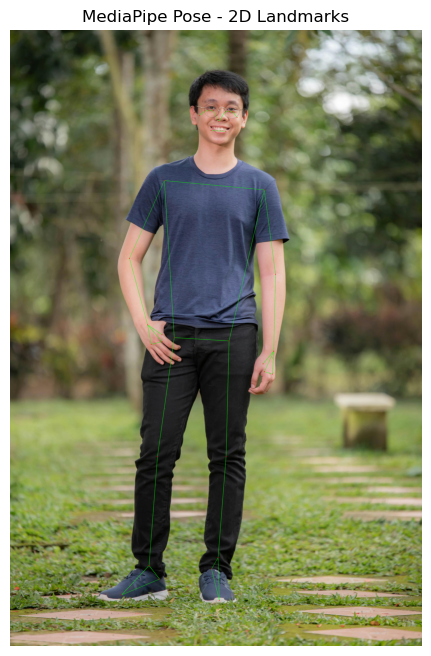

In [3]:
# copy image for drawing
annotated = img_rgb.copy()

# landmark connections
connections = mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS

# draw points + lines manually
if len(result.pose_landmarks) > 0:
    h, w, _ = annotated.shape
    pose_landmarks = result.pose_landmarks[0]

    # draw connections
    for conn in connections:
        start = pose_landmarks[conn.start]
        end = pose_landmarks[conn.end]

        x1, y1 = int(start.x * w), int(start.y * h)
        x2, y2 = int(end.x * w), int(end.y * h)

        cv2.line(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # draw landmarks
    for lm in pose_landmarks:
        x, y = int(lm.x * w), int(lm.y * h)
        cv2.circle(annotated, (x, y), 4, (255, 0, 0), -1)

plt.figure(figsize=(8, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("MediaPipe Pose - 2D Landmarks")
plt.show()

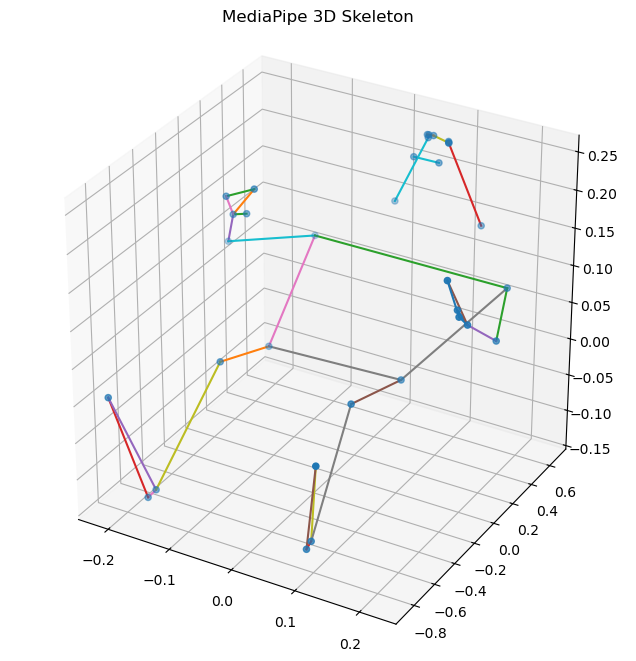

In [ ]:
connections = mp.solutions.pose.POSE_CONNECTIONS

world_landmarks = result.pose_world_landmarks[0]

xs = np.array([lm.x for lm in world_landmarks])
ys = np.array([lm.y for lm in world_landmarks])
zs = np.array([lm.z for lm in world_landmarks])

# fix orientation
ys = -ys
zs = -zs

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# draw joints
ax.scatter(xs, ys, zs)

# draw skeleton connections
for start, end in connections:
    ax.plot(
        [xs[start], xs[end]],
        [ys[start], ys[end]],
        [zs[start], zs[end]]
    )

ax.set_box_aspect([1,1,1])
plt.title("MediaPipe 3D Skeleton")
plt.show()